# Result | Strategy convergence timescales {#sec-results-strategy-convergence-timescales}

Here, we visualize the time steps required to reach the final strategies across different levels of environmental uncertainty. We start by importing the required packages, defining some configuations and obtaining the required simulation data.

In [1]:
#| output: asis
print("\\begin{OutputCode}") #| hide_line
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
plt.rcParams['text.usetex'] = True
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

from _code.ObtainNoiseVariationResults import obtain_all_noise_variation_comparisons, noise_levels
(NoiVar_MBA_pAhigh, NoiVar_MFA_pAhigh,
 NoiVar_MBA_pAmid, NoiVar_MFA_pAmid,
 NoiVar_MBA_pAlow, NoiVar_MFA_pAlow) = obtain_all_noise_variation_comparisons()
print("\\end{OutputCode}") #| hide_line

\begin{OutputCode}
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_LearningAgents_learning_rates0.25_initalX12842151645801287464_maxT5000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_SingleAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_LearningAgents_learning_rates0.25_initalX7794212447693859915_maxT5000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_ModelFreeAgents_learning_rates0.25_initalX12631382026377322370_maxT250000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_SingleAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_ModelFreeAgents_learning_rates0.25_initalX9145693657658906017_maxT250000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.58_likelydis

In [2]:
# Color palette (Okabe-Ito — colorblind-safe)
COLOR_SINGLE = "#0072B2"  # blue — single-agent environment
COLOR_SOCIAL = "#D55E00"  # vermillion — two-agent environment

We create a function to plot the time it takes for behaviors to converge under different noise levels and model assumptions. 

In [3]:
def plot_noise_variation(observable_Onk, noise_levels,
                          quartiles_color, observable_range,
                          ax=None):

    quartile1, medians, quartile3 = np.percentile(
            observable_Onk, [5, 50, 95], axis=1)

    ax.fill_between(noise_levels, quartile1, quartile3,
                        color=quartiles_color, alpha=0.5)
    ax.plot(noise_levels, medians, '-', color=quartiles_color)
    ax.set_ylim(*observable_range)

This function is then used in another fuction that visualizes the comparison between the single-agent and the two-agent environments.

In [4]:
def plot_behavior_convergence(NoiVar, maxT, ax=None):
    if ax is None:
        ax = plt.gca()

    params = dict(
        noise_levels=noise_levels,
        # number_of_bins_for_observable=51,
        observable_range=(0, maxT),
        # plot_means=False,
        # plot_histogram=False,
        ax=ax,
    )

    plot_noise_variation(
        observable_Onk=NoiVar.sa_Tnk, quartiles_color=COLOR_SINGLE, **params
    )

    plot_noise_variation(
        observable_Onk=NoiVar.ta_Tnk, quartiles_color=COLOR_SOCIAL, **params
    )
    
    xlim=[-0.05, max(noise_levels)+0.05]
    ax.set_xlim(xlim)
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.set_xlabel('Observational uncertainty $\\sigma$')
    ax.set_ylabel("Convergence steps")

This function yields, for example,

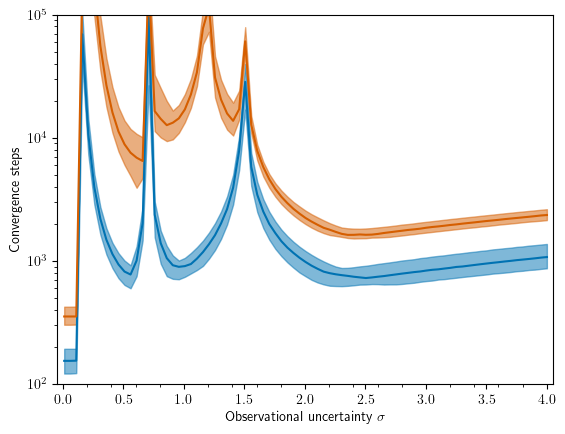

In [5]:
#| fig-cap: Example plot showing the time it takes for strategies to converge in the single-agent (blue) and two-agent (red) environments versus observational uncertainty.
plot_behavior_convergence(NoiVar_MFA_pAlow, maxT=2500)
plt.ylim(100, 100000); plt.yscale("log")

Again, we define the two helper functions to plot vertical lines to better visualize the critical levels of observational uncertainty where strategy transitions occur.

In [6]:
def plot_vertical_line_at_noise_level(ax, noise_level, ls='-'):
    ax.plot([noise_level, noise_level], ax.get_ylim(), ls, color='gray', lw=1.0)

In [7]:
def plot_vertical_lines_at_all_axes(axes, noise_level, ls='-'):
    for ax in axes: plot_vertical_line_at_noise_level(ax, noise_level, ls)

Putting everything together, we create the Figure 4 of the main text showing the learning time steps required.

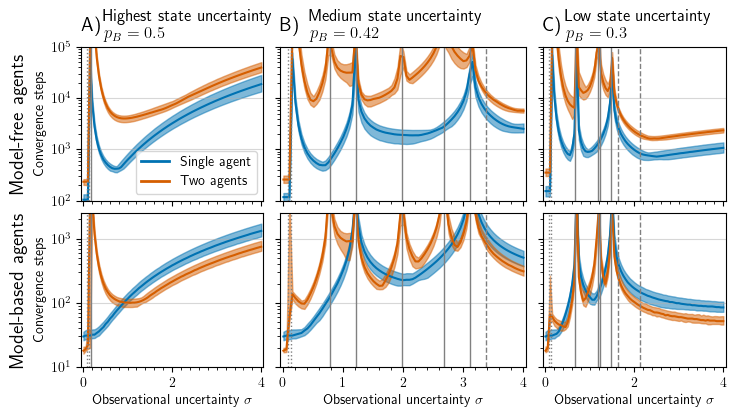

In [8]:
#| fig-cap: Figure 4 of the main text showing the learning times.
fsf = 0.260
fig = plt.figure(figsize=(fsf*32, fsf*16))

gs = GridSpec(2, 3, hspace=0.08, wspace=0.08,
              height_ratios=[1, 1], width_ratios=[1,1.35,1])

titleparams = dict(loc="left", x=0.12)
ABCparams = dict(xy=(0.0, 1.2), ha='left', va='top',
                 xycoords='axes fraction', fontsize=14, fontweight='bold')
maxT_MFA = 100000; maxT_MBA = 2500 
MFAylim = (100, maxT_MFA); MBAylim = (10, maxT_MBA); 

agentmodelparams = dict(
    xy=(-0.34, 0.5), rotation=90, fontsize=14, ha='center',
    va='center', xycoords='axes fraction', fontweight='bold') 

## 1 | Highest state uncertainty (p(A)=0.5)
ax_MFA_high = fig.add_subplot(gs[0, 0]); 
ax_MFA_high.set_title("Highest state uncertainty\n$p_B=0.5$", **titleparams)
ax_MFA_high.annotate("A)", **ABCparams)
plot_behavior_convergence(NoiVar_MFA_pAhigh, maxT=maxT_MFA, ax=ax_MFA_high)
ax_MFA_high.set_xlabel(""); ax_MFA_high.set_xticklabels([])
ax_MFA_high.set_ylabel("Convergence steps")
ax_MFA_high.annotate("Model-free agents", **agentmodelparams)
ax_MFA_high.set_ylim(MFAylim); ax_MFA_high.set_yscale("log")
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

ax_MBA_high = fig.add_subplot(gs[1, 0]);
plot_behavior_convergence(NoiVar_MBA_pAhigh, maxT=maxT_MBA, ax=ax_MBA_high)
ax_MBA_high.annotate("Model-based agents", **agentmodelparams)
ax_MBA_high.set_ylim(MBAylim); ax_MBA_high.set_yscale("log")
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

axes = [ax_MFA_high, ax_MBA_high]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.19)


## 2 | Medium state uncertainty (p(A)=0.6)
ax_MFA_mid = fig.add_subplot(gs[0, 1]);
ax_MFA_mid.set_title("Medium state uncertainty\n$p_B=0.42$", **titleparams)
ax_MFA_mid.annotate("B)", **ABCparams)
plot_behavior_convergence(NoiVar_MFA_pAmid, maxT=maxT_MFA, ax=ax_MFA_mid)
ax_MFA_mid.set_ylim(MFAylim); ax_MFA_mid.set_yscale("log")
ax_MFA_mid.set_ylabel(""); ax_MFA_mid.set_yticklabels([])
ax_MFA_mid.set_xlabel(""); ax_MFA_mid.set_xticklabels([])
plt.gca().grid(True, which='major', axis='y', alpha=0.5)


ax_MBA_mid = fig.add_subplot(gs[1, 1]);
plot_behavior_convergence(NoiVar_MBA_pAmid, maxT=maxT_MBA, ax=ax_MBA_mid)
ax_MBA_mid.set_ylim(MBAylim); ax_MBA_mid.set_yscale("log")
ax_MBA_mid.set_ylabel(""); ax_MBA_mid.set_yticklabels([])
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

axes = [ax_MFA_mid, ax_MBA_mid]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.78)
plot_vertical_lines_at_all_axes(axes, 1.22)
plot_vertical_lines_at_all_axes(axes, 1.98)
plot_vertical_lines_at_all_axes(axes, 2.68)
plot_vertical_lines_at_all_axes(axes, 3.11)
plot_vertical_lines_at_all_axes(axes, 3.38, ls="--")


## 3 | Lowest state uncertainty (p(A)=0.7)
ax_MFA_low = fig.add_subplot(gs[0, 2]);
ax_MFA_low.set_title("Low state uncertainty\n$p_B=0.3$", **titleparams)
ax_MFA_low.annotate("C)", **ABCparams)
plot_behavior_convergence(NoiVar_MFA_pAlow, maxT=maxT_MFA, ax=ax_MFA_low)
ax_MFA_low.set_ylim(MFAylim); ax_MFA_low.set_yscale("log")
ax_MFA_low.set_ylabel(""); ax_MFA_low.set_yticklabels([])
ax_MFA_low.set_xlabel(""); ax_MFA_low.set_xticklabels([])
plt.gca().grid(True, which='major', axis='y', alpha=0.5)


ax_MBA_low = fig.add_subplot(gs[1, 2]);
plot_behavior_convergence(NoiVar_MBA_pAlow, maxT=maxT_MBA, ax=ax_MBA_low)
ax_MBA_low.set_ylim(MBAylim); ax_MBA_low.set_yscale("log")
ax_MBA_low.set_ylabel(""); ax_MBA_low.set_yticklabels([]);
plt.gca().grid(True, which='major', axis='y', alpha=0.5)

axes = [ax_MFA_low, ax_MBA_low]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.68)
plot_vertical_lines_at_all_axes(axes, 1.18)
plot_vertical_lines_at_all_axes(axes, 1.23)
plot_vertical_lines_at_all_axes(axes, 1.48)
plot_vertical_lines_at_all_axes(axes, 1.63, ls="--")
plot_vertical_lines_at_all_axes(axes, 2.13, ls="--")

# Legend
legend_elements = [Line2D([0], [0], color=COLOR_SINGLE, lw=2, label='Single agent'),
                   Line2D([0], [0], color=COLOR_SOCIAL, lw=2, label='Two agents')]
ax_MFA_high.legend(handles=legend_elements, loc='lower right')

plt.savefig("./_figs/BehaviorConvergence.png", bbox_inches='tight', dpi=300)